# Chương 3 — Phân tích học dự đoán

**Huỳnh Thái Học** — Khoa Khoa học dữ liệu trong kinh doanh, Đại học Ngân hàng

Notebook thực hành từ câu hỏi kinh doanh đến mô hình Python và quyết định dựa
trên dữ liệu, bám theo quy trình **CRISP-DM**.

**Tình huống xuyên suốt:** ngân hàng muốn xác định khách hàng có khả năng phản
hồi chiến dịch mở thẻ tín dụng, nhằm ưu tiên liên hệ trong giới hạn nguồn lực.

> Dữ liệu mô phỏng phục vụ học tập. Chọn **Runtime → Run all** trên Colab.

## Chuẩn đầu ra thực hành

Sau notebook, sinh viên có thể:

1. Chuyển câu hỏi kinh doanh thành classification, regression, clustering hoặc association.
2. Thực hiện CRISP-DM và nhận diện data leakage.
3. Xây dựng pipeline tiền xử lý–mô hình không làm rò rỉ dữ liệu.
4. So sánh baseline, Logistic Regression và Decision Tree bằng holdout/CV.
5. Giải thích confusion matrix, precision, recall, F1, ROC–AUC và threshold.
6. Kết nối dự báo với chi phí, lợi ích và năng lực xử lý.
7. Thực hiện ví dụ ngắn về hồi quy, phân cụm và luật kết hợp.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_validate, learning_curve
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay,
    mean_absolute_error, mean_squared_error, silhouette_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
RANDOM_SEED = 42

## 1. Từ quyết định đến tác vụ phân tích

Hoàn thiện bảng sau trước khi viết mã:

| Câu hỏi | Task | Target | Đầu ra dùng cho quyết định |
|---|---|---|---|
| Khách nào sẽ phản hồi chiến dịch? | ... | ... | ... |
| Doanh thu tháng tới là bao nhiêu? | ... | ... | ... |
| Có những nhóm khách hàng tự nhiên nào? | ... | ... | ... |
| Sản phẩm nào thường được mua cùng nhau? | ... | ... | ... |

<details><summary><b>Gợi ý</b></summary>

Lần lượt là classification/CPE, regression, clustering và association rules.
Clustering và association không có target được gắn nhãn trước.
</details>

## 2. Business Understanding

Quyết định cần hỗ trợ: **chọn tối đa 25% khách hàng để ưu tiên liên hệ**.

- Người dùng mô hình: trưởng nhóm marketing.
- Positive class: khách hàng phản hồi (`response = 1`).
- Chi phí liên hệ: 30.000đ/khách.
- Lợi ích nếu khách phản hồi: 450.000đ/khách.
- Chi phí bỏ lỡ khách phản hồi cần được thảo luận riêng.

**Bài tập 1:** Viết tiêu chí thành công kinh doanh và kỹ thuật. Vì sao
`accuracy >= 90%` chưa chắc là tiêu chí phù hợp?

## 3. Sinh dữ liệu mô phỏng

**Grain:** một dòng là một khách hàng tại thời điểm trước khi gửi chiến dịch.
Các feature phải có sẵn ở thời điểm ra quyết định. Cột `response` chỉ được quan
sát sau chiến dịch và là target.

In [2]:
rng = np.random.default_rng(RANDOM_SEED)
n = 1800
age = rng.integers(20, 70, n)
income = np.round(rng.lognormal(np.log(18_000_000), 0.45, n), -3)
balance = np.round(rng.lognormal(np.log(45_000_000), 0.75, n), -3)
transactions = rng.poisson(18, n)
tenure = rng.integers(1, 181, n)
digital = rng.choice(["Thấp", "Trung bình", "Cao"], n, p=[.22, .46, .32])
region = rng.choice(["Miền Bắc", "Miền Trung", "Miền Nam"], n, p=[.33, .20, .47])
job = rng.choice(["Nhân viên", "Kinh doanh", "Quản lý", "Khác"], n,
                 p=[.46, .24, .14, .16])
previous_contact = rng.binomial(1, .28, n)

logit = (-4.1 + .035*(age-35) + .000000018*income
         + .028*transactions + .55*(digital == "Cao")
         + .35*(job == "Kinh doanh") + .75*previous_contact)
probability = 1 / (1 + np.exp(-logit))
response = rng.binomial(1, probability)

customers = pd.DataFrame({
    "customer_id": [f"KH{i:05d}" for i in range(1, n+1)],
    "age": age, "monthly_income": income, "avg_balance": balance,
    "transactions_3m": transactions, "tenure_months": tenure,
    "digital_usage": digital, "region": region, "job_group": job,
    "previous_contact": previous_contact, "response": response,
})

# Lỗi dữ liệu có chủ đích để luyện quy trình.
for col, count in {"monthly_income": 24, "digital_usage": 18}.items():
    customers.loc[rng.choice(customers.index, count, replace=False), col] = np.nan
customers.head()

,customer_id,age,monthly_income,avg_balance,transactions_3m,tenure_months,digital_usage,region,job_group,previous_contact,response
0,KH00001,24,13835000.0,44333000.0,16,60,Trung bình,Miền Nam,Nhân viên,0,0
1,KH00002,58,17627000.0,27518000.0,14,108,Thấp,Miền Bắc,Nhân viên,0,0
2,KH00003,52,20407000.0,75562000.0,11,129,Trung bình,Miền Bắc,Khác,0,0
3,KH00004,41,11437000.0,132111000.0,22,122,Cao,Miền Trung,Nhân viên,1,0
4,KH00005,41,24936000.0,31765000.0,25,26,Thấp,Miền Trung,Nhân viên,0,0


In [3]:
print("Kích thước:", customers.shape)
print("Tỷ lệ phản hồi:", f"{customers['response'].mean():.2%}")
display(pd.DataFrame({
    "dtype": customers.dtypes.astype(str),
    "missing": customers.isna().sum(),
    "n_unique": customers.nunique(dropna=True),
}))
assert customers["customer_id"].is_unique

Kích thước: (1800, 11)
Tỷ lệ phản hồi: 10.00%


,dtype,missing,n_unique
customer_id,object,0,1800
age,int64,0,50
monthly_income,float64,24,1725
avg_balance,float64,0,1786
transactions_3m,int64,0,28
tenure_months,int64,0,180
digital_usage,object,18,3
region,object,0,3
job_group,object,0,4
previous_contact,int64,0,2


### Bài tập 2 — Data Understanding

1. Target có mất cân bằng không?
2. Feature nào là numeric/categorical?
3. `customer_id` có nên là feature không?
4. Missing nên được xử lý trước hay bên trong pipeline? Giải thích.
5. Chỉ ra ít nhất hai vấn đề công bằng/đạo đức cần kiểm tra.

## 4. Data Leakage và thời điểm quyết định

Đoạn dưới tạo `accepted_card`, chỉ phát sinh **sau** khi khách phản hồi. Nếu đưa
vào feature, mô hình đang dùng tương lai để dự đoán quá khứ.

In [4]:
customers["accepted_card"] = np.where(
    customers["response"].eq(1), rng.binomial(1, .82, n), 0
)
leakage_table = pd.crosstab(customers["accepted_card"], customers["response"], normalize="index")
leakage_table

response,0,1
accepted_card,,
0,0.979444,0.020556
1,0.000000,1.000000


**Bài tập 3:** Vẽ trục thời gian cho `previous_contact`, `response` và
`accepted_card`. Feature nào được phép dùng? Sau đó liệt kê thêm ba ví dụ
leakage trong ngân hàng.

> Trong các mô hình bên dưới, `accepted_card` bị loại hoàn toàn.

## 5. Chia train/test trước khi học quy tắc từ dữ liệu

Tập test được giữ riêng để ước lượng khả năng tổng quát hóa. `stratify=y` giữ
tỷ lệ positive gần giống nhau ở train và test.

In [5]:
target = "response"
features = [
    "age", "monthly_income", "avg_balance", "transactions_3m",
    "tenure_months", "digital_usage", "region", "job_group",
    "previous_contact",
]
X = customers[features]
y = customers[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.25, stratify=y, random_state=RANDOM_SEED
)
print("Train:", X_train.shape, f"positive={y_train.mean():.2%}")
print("Test :", X_test.shape, f"positive={y_test.mean():.2%}")

Train: (1350, 9) positive=10.00%
Test : (450, 9) positive=10.00%


## 6. Pipeline tiền xử lý

Imputer, scaler và encoder chỉ `fit` trên train thông qua Pipeline. Đây là cách
tránh leakage từ thống kê của tập test.

In [6]:
numeric_features = ["age", "monthly_income", "avg_balance",
                    "transactions_3m", "tenure_months", "previous_contact"]
categorical_features = ["digital_usage", "region", "job_group"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

## 7. Baseline trước mô hình phức tạp

Baseline `most_frequent` luôn đoán lớp phổ biến. Accuracy của baseline có thể
cao khi dữ liệu mất cân bằng, nhưng recall positive sẽ bằng 0.

In [7]:
baseline = Pipeline([
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent")),
])
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_metrics = {
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall": recall_score(y_test, baseline_pred, zero_division=0),
    "f1": f1_score(y_test, baseline_pred, zero_division=0),
}
pd.Series(baseline_metrics).round(3)

accuracy     0.9
precision    0.0
recall       0.0
f1           0.0
dtype: float64

### Bài tập 4 — Đọc baseline

Giải thích vì sao mô hình có thể đạt accuracy cao nhưng không tìm được khách
hàng phản hồi nào. Metric nào cần ưu tiên nếu chi phí bỏ lỡ khách tiềm năng lớn?

## 8. Logistic Regression và Decision Tree

In [8]:
logistic = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                 random_state=RANDOM_SEED)),
])
tree = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(max_depth=4, min_samples_leaf=30,
                                     class_weight="balanced",
                                     random_state=RANDOM_SEED)),
])

models = {"Baseline": baseline, "Logistic": logistic, "Decision Tree": tree}
for model in models.values():
    model.fit(X_train, y_train)

In [9]:
def classification_metrics(name, model, X_eval, y_eval, threshold=.5):
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_eval)[:, 1]
        pred = (score >= threshold).astype(int)
        auc = roc_auc_score(y_eval, score)
    else:
        pred = model.predict(X_eval)
        score = pred
        auc = np.nan
    return {
        "model": name, "threshold": threshold,
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall": recall_score(y_eval, pred, zero_division=0),
        "f1": f1_score(y_eval, pred, zero_division=0), "roc_auc": auc,
    }

comparison = pd.DataFrame([
    classification_metrics(name, model, X_test, y_test)
    for name, model in models.items()
])
comparison.round(3)

,model,threshold,accuracy,precision,recall,f1,roc_auc
0,Baseline,0.5,0.900,0.000,0.000,0.000,0.500
1,Logistic,0.5,0.651,0.167,0.622,0.263,0.687
2,Decision Tree,0.5,0.682,0.155,0.489,0.235,0.616


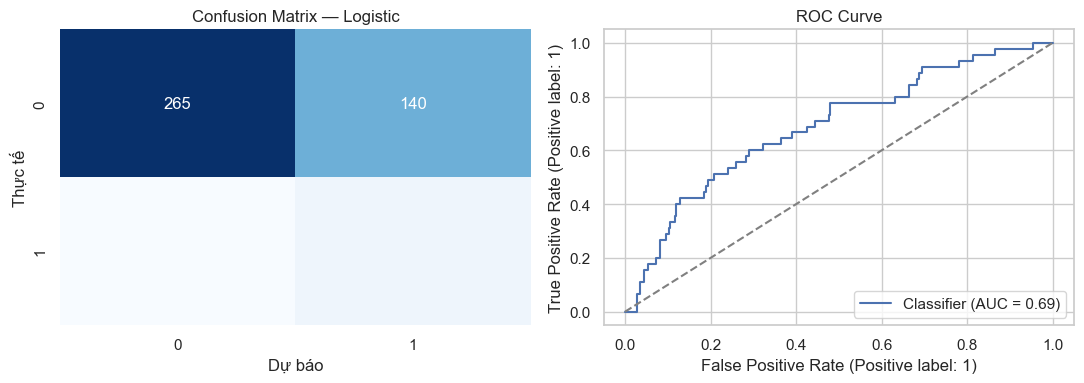

In [10]:
logistic_score = logistic.predict_proba(X_test)[:, 1]
logistic_pred = (logistic_score >= .5).astype(int)
cm = confusion_matrix(y_test, logistic_pred)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set(title="Confusion Matrix — Logistic", xlabel="Dự báo", ylabel="Thực tế")
RocCurveDisplay.from_predictions(y_test, logistic_score, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("ROC Curve")
plt.tight_layout(); plt.show()

### Bài tập 5 — Ma trận nhầm lẫn

Từ `cm`, xác định TN, FP, FN, TP. Viết chi phí kinh doanh của FP và FN trong
chiến dịch. Không kết luận một metric là tốt nhất khi chưa biết chi phí này.

## 9. Entropy, Information Gain và cây quyết định

In [11]:
def entropy(labels):
    probabilities = pd.Series(labels).value_counts(normalize=True)
    return float(-(probabilities * np.log2(probabilities)).sum())

parent_entropy = entropy(y_train)
split_feature = X_train["previous_contact"]
weighted_child_entropy = sum(
    (mask.mean() * entropy(y_train[mask]))
    for value in split_feature.unique()
    if (mask := split_feature.eq(value)).any()
)
information_gain = parent_entropy - weighted_child_entropy
print(f"Entropy target: {parent_entropy:.4f}")
print(f"Information Gain của previous_contact: {information_gain:.4f}")

Entropy target: 0.4690
Information Gain của previous_contact: 0.0128


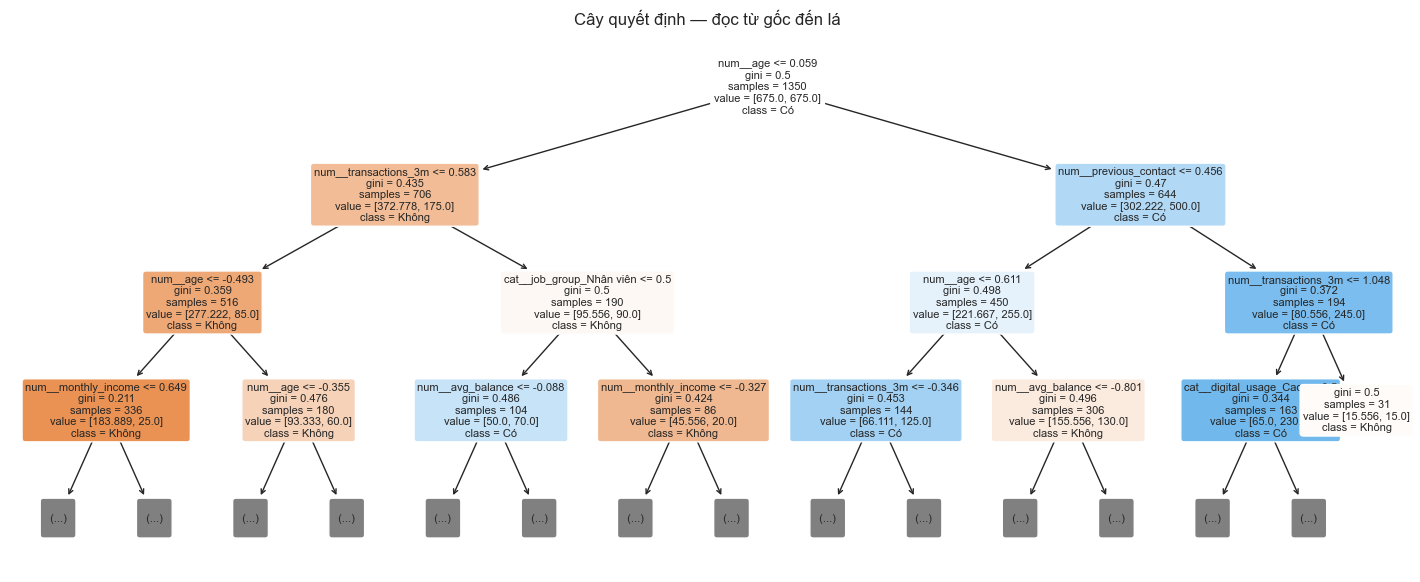

In [12]:
feature_names = tree.named_steps["preprocess"].get_feature_names_out()
tree_model = tree.named_steps["model"]
plt.figure(figsize=(18, 7))
plot_tree(tree_model, feature_names=feature_names, class_names=["Không", "Có"],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.title("Cây quyết định — đọc từ gốc đến lá")
plt.show()

### Bài tập 6 — Chuyển cây thành luật

Chọn một đường từ nút gốc đến nút lá và viết lại thành luật `IF ... THEN ...`.
Nêu population của lá và tỷ lệ positive; tránh diễn giải split là quan hệ nhân quả.

## 10. Cross-validation và overfitting

Cross-validation chỉ chạy trên train. Test vẫn được giữ lại cho đánh giá cuối.

In [13]:
scoring = {"accuracy": "accuracy", "precision": "precision",
           "recall": "recall", "f1": "f1", "auc": "roc_auc"}
cv_rows = []
for name, model in {"Logistic": logistic, "Decision Tree": tree}.items():
    scores = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)
cv_results = pd.DataFrame(cv_rows)
cv_results.round(3)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std
0,Logistic,0.675,0.025,0.181,0.033,0.637,0.123,0.281,0.052,0.715,0.084
1,Decision Tree,0.677,0.041,0.143,0.020,0.444,0.102,0.215,0.031,0.615,0.026


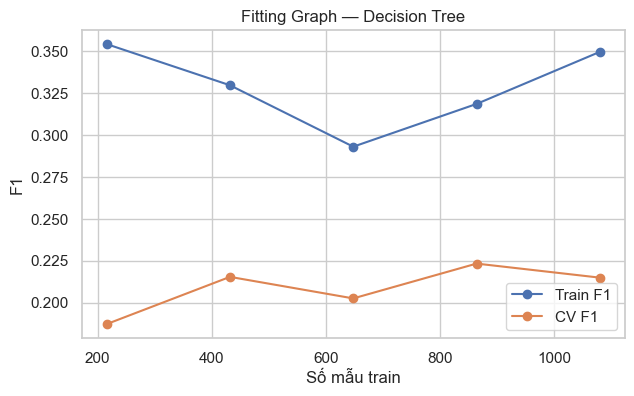

In [14]:
train_sizes, train_scores, valid_scores = learning_curve(
    tree, X_train, y_train, cv=5, scoring="f1",
    train_sizes=np.linspace(.2, 1.0, 5), n_jobs=None
)
plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train F1")
plt.plot(train_sizes, valid_scores.mean(axis=1), marker="o", label="CV F1")
plt.xlabel("Số mẫu train"); plt.ylabel("F1"); plt.title("Fitting Graph — Decision Tree")
plt.legend(); plt.show()

### Bài tập 7 — Kiểm soát overfitting

Thử `max_depth=None` và `min_samples_leaf=1`, rồi so sánh Train F1 với CV F1.
Nếu khoảng cách tăng mạnh, mô hình đang gặp vấn đề gì? Đề xuất hai cách kiểm soát.

## 11. Threshold, nguồn lực và lợi nhuận

Threshold 0.5 không tự động là ngưỡng kinh doanh tốt nhất. Ta so sánh các
ngưỡng bằng metric và giá trị ròng, sau đó áp dụng giới hạn liên hệ tối đa 25%.

In [15]:
CONTACT_COST = 30_000
RESPONSE_BENEFIT = 450_000

def evaluate_threshold(y_true, scores, threshold):
    selected = scores >= threshold
    tp = int((selected & y_true.eq(1).to_numpy()).sum())
    fp = int((selected & y_true.eq(0).to_numpy()).sum())
    fn = int((~selected & y_true.eq(1).to_numpy()).sum())
    contacted = int(selected.sum())
    net_value = tp * RESPONSE_BENEFIT - contacted * CONTACT_COST
    return {"threshold": threshold, "contacted": contacted, "TP": tp,
            "FP": fp, "FN": fn, "net_value": net_value}

threshold_table = pd.DataFrame([
    evaluate_threshold(y_test.reset_index(drop=True), logistic_score, t)
    for t in np.arange(.10, .91, .05)
])
threshold_table["contact_rate"] = threshold_table["contacted"] / len(y_test)
threshold_table.sort_values("net_value", ascending=False).head(8)

,threshold,contacted,TP,FP,FN,net_value,contact_rate
6,0.40,237,35,202,10,8640000,0.526667
2,0.20,379,43,336,2,7980000,0.842222
3,0.25,350,41,309,4,7950000,0.777778
4,0.30,309,38,271,7,7830000,0.686667
5,0.35,270,35,235,10,7650000,0.600000
8,0.50,168,28,140,17,7560000,0.373333
7,0.45,201,30,171,15,7470000,0.446667
1,0.15,411,44,367,1,7470000,0.913333


In [16]:
capacity = int(np.floor(.25 * len(y_test)))
ranked = pd.DataFrame({"actual": y_test.to_numpy(), "score": logistic_score})
ranked = ranked.sort_values("score", ascending=False).reset_index(drop=True)
ranked["selected"] = ranked.index < capacity

tp_capacity = int((ranked["selected"] & ranked["actual"].eq(1)).sum())
net_capacity = tp_capacity * RESPONSE_BENEFIT - capacity * CONTACT_COST
print(f"Năng lực liên hệ: {capacity} khách ({capacity/len(y_test):.0%})")
print(f"Số phản hồi tìm đúng: {tp_capacity}")
print(f"Giá trị ròng trên holdout: {net_capacity:,.0f} đ")

Năng lực liên hệ: 112 khách (25%)
Số phản hồi tìm đúng: 23
Giá trị ròng trên holdout: 6,990,000 đ


### Bài tập 8 — Chọn ngưỡng có trách nhiệm

1. Chọn threshold tối đa hóa `net_value` trong bảng.
2. Kiểm tra threshold đó có vi phạm giới hạn 25% không.
3. So sánh chọn theo threshold với chọn Top 25% score.
4. Thực hiện phân tích độ nhạy khi chi phí liên hệ tăng gấp đôi.
5. Nêu nhóm khách hàng cần kiểm tra fairness trước triển khai.

## 12. Nhánh Regression — dự báo giá trị số

Ví dụ dự báo chi tiêu tháng tới. Baseline mean phải được so sánh trước Linear
Regression và Regression Tree; metric là MAE/RMSE, không dùng accuracy.

In [17]:
reg_df = customers.dropna(subset=["monthly_income"]).copy()
noise = rng.normal(0, 1_500_000, len(reg_df))
reg_df["next_month_spend"] = (
    700_000 + .035*reg_df["monthly_income"] + 42_000*reg_df["transactions_3m"]
    + 250_000*reg_df["previous_contact"] + noise
).clip(0)

reg_features = ["monthly_income", "avg_balance", "transactions_3m", "tenure_months"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    reg_df[reg_features], reg_df["next_month_spend"], test_size=.25,
    random_state=RANDOM_SEED
)
reg_preprocess = Pipeline([("imputer", SimpleImputer(strategy="median")),
                           ("scaler", StandardScaler())])
reg_models = {
    "Baseline mean": Pipeline([("prep", reg_preprocess), ("model", DummyRegressor())]),
    "Linear": Pipeline([("prep", reg_preprocess), ("model", LinearRegression())]),
    "Tree": Pipeline([("prep", reg_preprocess),
                      ("model", DecisionTreeRegressor(max_depth=4, min_samples_leaf=25,
                                                      random_state=RANDOM_SEED))]),
}
reg_results = []
for name, model in reg_models.items():
    model.fit(Xr_train, yr_train)
    pred = model.predict(Xr_test)
    reg_results.append({"model": name,
                        "MAE": mean_absolute_error(yr_test, pred),
                        "RMSE": mean_squared_error(yr_test, pred, squared=False)})
pd.DataFrame(reg_results).round(0)

,model,MAE,RMSE
0,Baseline mean,1137329.0,1407668.0
1,Linear,1103847.0,1377455.0
2,Tree,1118816.0,1397659.0


### Bài tập 9 — Đánh giá hồi quy

Mô hình nào cải thiện nhiều nhất so với baseline? Diễn giải MAE bằng đơn vị
đồng. Vẽ actual–predicted và kiểm tra sai số có tăng theo mức chi tiêu không.

## 13. Nhánh Clustering — phân khúc không có target

Scaling là bắt buộc vì income/balance có đơn vị lớn hơn transactions. Cluster
chỉ là nhóm toán học; cần mô tả trước khi đặt tên kinh doanh.

In [18]:
cluster_features = ["monthly_income", "avg_balance", "transactions_3m"]
cluster_data = customers[cluster_features].copy()
cluster_matrix = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
]).fit_transform(cluster_data)

cluster_scores = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit_predict(cluster_matrix)
    cluster_scores.append({"k": k, "silhouette": silhouette_score(cluster_matrix, labels)})
pd.DataFrame(cluster_scores)

,k,silhouette
0,2,0.239670
1,3,0.267974
2,4,0.298378
3,5,0.300738
4,6,0.257351


In [19]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_SEED)
customers["cluster"] = kmeans.fit_predict(cluster_matrix)
cluster_profile = (customers.groupby("cluster")
                   .agg(customers=("customer_id", "size"),
                        income_median=("monthly_income", "median"),
                        balance_median=("avg_balance", "median"),
                        transactions_mean=("transactions_3m", "mean"),
                        response_rate=("response", "mean")))
cluster_profile.round(2)

,customers,income_median,balance_median,transactions_mean,response_rate
cluster,,,,,
0,153,18770000.0,166397000.0,17.18,0.10
1,772,19991500.0,40752000.0,21.58,0.13
2,875,16073500.0,42857000.0,15.05,0.08


### Bài tập 10 — Diễn giải cụm có trách nhiệm

Mô tả từng cụm bằng số liệu, rồi mới đề xuất tên trung tính. Vì sao không nên
gọi một cụm là “khách hàng xấu”? Kiểm tra kích thước và phân bố vùng của mỗi cụm.

## 14. Nhánh Association Rules — giỏ hàng

Ví dụ dưới tính support, confidence và lift bằng Python thuần, không bắt buộc
cài `mlxtend`.

In [20]:
from itertools import combinations

baskets = [
    {"Sữa", "Bánh mì", "Trứng"}, {"Bia", "Snack"},
    {"Sữa", "Bánh mì"}, {"Bia", "Snack", "Nước ngọt"},
    {"Sữa", "Trứng"}, {"Bánh mì", "Trứng"},
    {"Bia", "Snack"}, {"Sữa", "Bánh mì", "Snack"},
    {"Bia", "Nước ngọt"}, {"Sữa", "Bánh mì", "Trứng"},
]

def support(itemset):
    itemset = set(itemset)
    return sum(itemset <= basket for basket in baskets) / len(baskets)

def rule_metrics(antecedent, consequent):
    both = set(antecedent) | set(consequent)
    sup = support(both)
    conf = sup / support(antecedent)
    lift = conf / support(consequent)
    return {"rule": f"{antecedent} → {consequent}", "support": sup,
            "confidence": conf, "lift": lift}

rules = [
    rule_metrics(("Sữa",), ("Bánh mì",)),
    rule_metrics(("Bia",), ("Snack",)),
    rule_metrics(("Trứng",), ("Sữa",)),
]
pd.DataFrame(rules).round(3)

,rule,support,confidence,lift
0,"('Sữa',) → ('Bánh mì',)",0.4,0.80,1.600
1,"('Bia',) → ('Snack',)",0.3,0.75,1.875
2,"('Trứng',) → ('Sữa',)",0.3,0.75,1.500


### Bài tập 11 — Không nhầm kết hợp với nhân quả

1. Giải thích một luật có lift > 1.
2. Vì sao confidence cao vẫn có thể gây hiểu lầm khi consequent rất phổ biến?
3. Luật `Bia → Snack` có chứng minh bia làm khách mua snack không?
4. Nêu hành động A/B test phù hợp trước khi thay đổi trưng bày.

## 15. Bài tập tích hợp CRISP-DM mini

Chọn một trong bốn nhánh: classification, regression, clustering hoặc
association. Notebook nộp phải có:

1. **Business Understanding:** quyết định, người dùng, task, target/đầu ra, chi phí–lợi ích.
2. **Data Understanding:** grain, feature, target, missing, imbalance và thời điểm dữ liệu.
3. **Data Preparation:** split trước; preprocessing trong Pipeline; giải thích chống leakage.
4. **Modeling:** baseline và ít nhất hai mô hình/phương án phù hợp.
5. **Evaluation:** holdout, cross-validation hoặc metric phù hợp; phân tích overfitting.
6. **Deployment:** score/pattern được dùng như thế nào; threshold/ràng buộc; cách giám sát.
7. Ba insight theo cấu trúc **Quan sát → Ý nghĩa → Hành động**.

### Rubric tự đánh giá (10 điểm)

| Tiêu chí | Điểm |
|---|---:|
| Business understanding và chọn đúng task | 1.5 |
| Hiểu dữ liệu, grain, target và leakage | 1.5 |
| Pipeline Python sạch, tái lập được | 2.0 |
| Baseline, mô hình và đánh giá đúng | 2.0 |
| Diễn giải metric, chi phí–lợi ích và ràng buộc | 2.0 |
| Trình bày, nguồn và trách nhiệm | 1.0 |

## Exit ticket

Ngân hàng muốn dự đoán khách hàng đồng ý mở thẻ tín dụng:

1. Task và target là gì?
2. Feature nào có nguy cơ leakage?
3. Baseline nào phù hợp?
4. Nếu năng lực liên hệ chỉ 10%, nên dùng nhãn 0/1 hay probability/ranking?
5. Metric kỹ thuật và KPI kinh doanh nào cần theo dõi sau triển khai?

> Mô hình hỗ trợ quyết định; người quản lý vẫn chịu trách nhiệm về mục tiêu,
> ngưỡng, chính sách, công bằng và tác động sau triển khai.